# Задание 1. Реализация AprioriAll

In [21]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install networkx
!pip install prefixspan


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for prefixspan: filename=prefixspan-0.5.2-py3-none-any.whl size=11371 sha256=23048f00dc3e4550066a4b451fc5ba26856a52f209e6cc088a23d26f646d0695
  Stored in directory: c:\users\ilipa\appdata\local\pip\cache\wheels\d0\4a\de\192072146c56cc4ee4d9669c4d0ffdeabbc8dfc4759f397d4e
  Created wheel for extratools: filename=extratools-0


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import itertools
from collections import defaultdict, Counter
from typing import List, Set, Tuple, Dict, Optional, Any

def apriori(transactions: List[Set], min_support: float) -> Dict[Tuple, float]:
    """
    Реализация алгоритма Apriori.

    Параметры:
        transactions (List[Set]): список транзакций, каждая транзакция — множество уникальных элементов.
        min_support (float): минимальная поддержка (доля от общего числа транзакций).

    Возвращает:
        Dict[Tuple, float]: словарь {itemset_tuple: support_value},
        где itemset_tuple — отсортированный кортеж элементов,
        support_value — доля транзакций, содержащих данный набор.
    """
    n = len(transactions)
    min_count = min_support * n
    if min_count < 1:
        min_count = 1
    else:
        min_count = int(min_count)
    
    # Частые 1-элементы
    item_counts = Counter()
    for trans in transactions:
        item_counts.update(trans)
    freq_itemsets = {(item,): cnt/n for item, cnt in item_counts.items() if cnt >= min_count}
    
    if not freq_itemsets:
        return {}
    
    # Переводим транзакции в frozenset для быстрой проверки подмножества
    trans_sets = [frozenset(t) for t in transactions]
    prev_itemsets = list(freq_itemsets.keys())
    k = 2
    
    while prev_itemsets:
        freq_set_lookup = {frozenset(itemset): True for itemset in prev_itemsets}
        
        candidates_sets = apriori_gen(prev_itemsets, freq_set_lookup, k)
        if not candidates_sets:
            break
        
        candidates_fs = [frozenset(cand) for cand in candidates_sets]
        
        # Подсчёт поддержки
        support_counts = Counter()
        for trans in trans_sets:
            for cand in candidates_fs:
                if cand.issubset(trans):
                    support_counts[cand] += 1
        
        # Фильтрация и добавление новых частых
        new_freq = {}
        for cand, cnt in support_counts.items():
            if cnt >= min_count:
                itemset_tuple = tuple(sorted(cand))
                new_freq[itemset_tuple] = cnt / n
        
        if not new_freq:
            break
        
        freq_itemsets.update(new_freq)
        prev_itemsets = list(new_freq.keys())
        k += 1
    
    return freq_itemsets


def apriori_gen(prev_itemsets: List[Tuple], freq_set_lookup: Dict[frozenset, bool], k: int) -> List[Set]:
    """
    Генерация кандидатов длины k из частых наборов длины k-1.
    """
    candidates = []
    n = len(prev_itemsets)
    for i in range(n):
        for j in range(i + 1, n):
            # Объединяем два (k-1)-набора
            set1 = set(prev_itemsets[i])
            set2 = set(prev_itemsets[j])
            
            list1 = sorted(set1)
            list2 = sorted(set2)
            if list1[:k-2] == list2[:k-2]:
                # Добавляем различающийся элемент
                new_cand_set = set1 | set2
                if len(new_cand_set) == k:
                    subsets_ok = True
                    for sub in itertools.combinations(new_cand_set, k-1):
                        if frozenset(sub) not in freq_set_lookup:
                            subsets_ok = False
                            break
                    if subsets_ok:
                        candidates.append(new_cand_set)
    return candidates


def generate_rules(
    frequent_itemsets: Dict[Tuple, float],
    min_confidence: float,
    min_lift: float = 1.0,
    max_antecedent_len: Optional[int] = None,
    max_consequent_len: Optional[int] = None
) -> List[Tuple[Tuple, Tuple, float, float, float, float, float]]:
    """
    Генерация ассоциативных правил из частых наборов.

    Параметры:
        frequent_itemsets (Dict[Tuple, float]): словарь частых наборов {itemset: support}.
        min_confidence (float): минимальная достоверность.
        min_lift (float): минимальный lift (по умолчанию 1.0).
        max_antecedent_len (Optional[int]): максимальная длина левой части (антецедента).
        max_consequent_len (Optional[int]): максимальная длина правой части (консеквента).

    Возвращает:
        List[Tuple]: список правил, каждое правило представлено кортежем:
        (antecedent, consequent, support, confidence, lift, conviction, leverage).
        antecedent и consequent — отсортированные кортежи элементов.
    """
    rules = []

    for itemset, support_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        itemset_set = set(itemset)
        # Все непустые собственные подмножества
        for r in range(1, len(itemset)):
            for antecedent in itertools.combinations(itemset, r):
                antecedent = tuple(sorted(antecedent))
                consequent = tuple(sorted(itemset_set - set(antecedent)))

                # Проверка ограничений на длину
                if max_antecedent_len is not None and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len is not None and len(consequent) > max_consequent_len:
                    continue

                support_x = frequent_itemsets.get(antecedent, 0.0)
                if support_x == 0.0:
                    continue
                support_y = frequent_itemsets.get(consequent, 0.0)

                confidence = support_xy / support_x
                if confidence < min_confidence:
                    continue

                lift = confidence / support_y if support_y > 0 else float('inf')
                if lift < min_lift:
                    continue

                conviction = (1 - support_y) / (1 - confidence) if confidence < 1 else float('inf')
                leverage = support_xy - support_x * support_y

                rules.append((antecedent, consequent, support_xy, confidence, lift, conviction, leverage))

    return rules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict, Counter
from itertools import combinations
import datetime
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Online Retail.csv', sep=';')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d.%m.%Y %H:%M', errors='coerce')
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace(',', '.').astype(float)
df['InvoiceNo'] = df['InvoiceNo'].astype('category')
df['StockCode'] = df['StockCode'].astype('category')
df['Country'] = df['Country'].astype('category')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['UnitPrice'] > 0) & (df['Quantity'] > 0)]
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"Размер после очистки: {len(df)}")
print(f"Уникальных клиентов: {df['CustomerID'].nunique()}")
print(f"Уникальных товаров: {df['StockCode'].nunique()}")

transactions_apriori = (
    df.groupby('InvoiceNo')['StockCode']
      .apply(lambda x: set(x))
      .tolist()
)
print(f"Всего транзакций для Apriori: {len(transactions_apriori)}")

temp = (
    df.groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate'])['StockCode']
      .apply(frozenset)
      .reset_index()
      .sort_values(['CustomerID', 'InvoiceDate'])
)
customer_seq_dates = temp.groupby('CustomerID').apply(
    lambda g: list(zip(g['InvoiceDate'], g['StockCode']))
).tolist()

customer_sequences = [[items for _, items in seq] for seq in customer_seq_dates]
customer_sequences = [seq for seq in customer_sequences if len(seq) >= 2]
print(f"Клиентов с ≥2 транзакциями: {len(customer_sequences)}")

Размер после очистки: 397884
Уникальных клиентов: 4338
Уникальных товаров: 3665
Всего транзакций для Apriori: 18532
Клиентов с ≥2 транзакциями: 2847


In [3]:
def is_subsequence(subseq, fullseq):
    it = iter(fullseq)
    for itemset in subseq:
        found = False
        for cand in it:
            if itemset.issubset(cand):
                found = True
                break
        if not found:
            return False
    return True

def apriori_all(sequences, min_support):
    """
    Поиск частых последовательностей с поддержкой по клиентам.
    
    Параметры:
        sequences: list of list of frozenset – клиентские последовательности
        min_support: float – минимальная поддержка (доля клиентов)
    
    Возвращает:
        dict {tuple of frozenset: support}
    """
    n_clients = len(sequences)
    min_count = max(1, int(min_support * n_clients))
    
    # 1-элементные последовательности (единичные товары)
    item_counts = Counter()
    for seq in sequences:
        unique_items = set()
        for trans in seq:
            unique_items.update(trans)
        for item in unique_items:
            item_counts[item] += 1
    
    freq1 = {(frozenset([item]),): cnt / n_clients for item, cnt in item_counts.items() if cnt >= min_count}
    all_freq = dict(freq1)
    prev_freq = list(freq1.keys())
    
    k = 2
    while prev_freq:
        candidates = set()
        # Объединение последовательностей, имеющих общий префикс длины k-2
        for i in range(len(prev_freq)):
            for j in range(len(prev_freq)):
                seq_i = prev_freq[i]
                seq_j = prev_freq[j]
                if seq_i[:-1] == seq_j[:-1]:
                    new_seq = seq_i + (seq_j[-1],)
                    candidates.add(new_seq)
        
        # Добавление одного частого 1-itemset ко всем частым (k-1)-последовательностям
        for seq in prev_freq:
            for itemset_tuple, _ in freq1.items():
                candidates.add(seq + itemset_tuple)
        
        # Отсечение: все (k-1)-подпоследовательности должны быть частыми
        valid_candidates = []
        for cand in candidates:
            ok = True
            for i in range(len(cand)):
                sub = cand[:i] + cand[i+1:]
                if sub not in all_freq:
                    ok = False
                    break
            if ok:
                valid_candidates.append(cand)
        
        if not valid_candidates:
            break
        
        # Подсчёт поддержки
        counts = defaultdict(int)
        for seq in sequences:
            for cand in valid_candidates:
                if is_subsequence(cand, seq):
                    counts[cand] += 1
        
        curr_freq = {}
        for cand, cnt in counts.items():
            if cnt >= min_count:
                all_freq[cand] = cnt / n_clients
                curr_freq[cand] = all_freq[cand]
        
        prev_freq = list(curr_freq.keys())
        k += 1
    
    return all_freq

synth_seqs = [
    [frozenset([1,5]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([4]), frozenset([3,5])],
    [frozenset([1]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([5]), frozenset([4])],
    [frozenset([4]), frozenset([5])]
]

freq_synth = apriori_all(synth_seqs, 0.4)
print("Проверка на синтетических данных (min_sup=0.4):")
for seq, sup in sorted(freq_synth.items(), key=lambda x: (-len(x[0]), -x[1])):
    if len(seq) == 1:
        print(f"<{set(seq[0])}> : {sup:.2f}")
    else:
        s = " -> ".join([str(set(it)) for it in seq])
        print(f"<{s}> : {sup:.2f}")

Проверка на синтетических данных (min_sup=0.4):
<{1} -> {2} -> {3} -> {4}> : 0.40
<{1} -> {3} -> {4}> : 0.80
<{1} -> {2} -> {4}> : 0.40
<{2} -> {3} -> {4}> : 0.40
<{1} -> {2} -> {3}> : 0.40
<{1} -> {3} -> {5}> : 0.40
<{3} -> {4}> : 0.80
<{1} -> {3}> : 0.80
<{1} -> {4}> : 0.80
<{2} -> {4}> : 0.40
<{5} -> {4}> : 0.40
<{1} -> {2}> : 0.40
<{2} -> {3}> : 0.40
<{3} -> {5}> : 0.40
<{4} -> {5}> : 0.40
<{1} -> {5}> : 0.40
<{4}> : 1.00
<{1}> : 0.80
<{3}> : 0.80
<{5}> : 0.80
<{2}> : 0.40


# Задание 2. Анализ реальных данных

min_sup=5%: 725 частых последовательностей
min_sup=10%: 103 частых последовательностей
min_sup=20%: 3 частых последовательностей


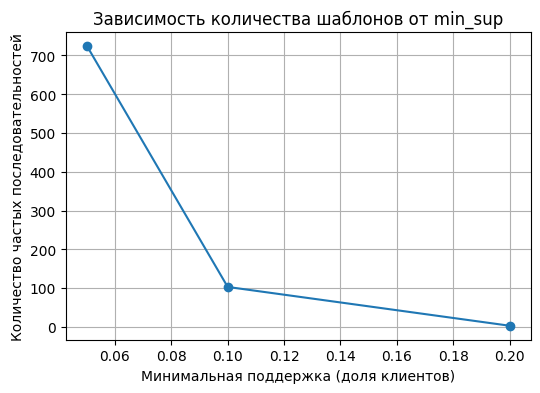

Вывод: число шаблонов экспоненциально убывает с ростом порога, что говорит о хорошей масштабируемости алгоритма.


In [7]:
min_sups = [0.05, 0.10, 0.20]
results = {}
for ms in min_sups:
    freq = apriori_all(customer_sequences, ms)
    results[ms] = freq
    print(f"min_sup={ms:.0%}: {len(freq)} частых последовательностей")

plt.figure(figsize=(6,4))
plt.plot(min_sups, [len(results[ms]) for ms in min_sups], marker='o')
plt.xlabel('Минимальная поддержка (доля клиентов)')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость количества шаблонов от min_sup')
plt.grid(True)
plt.show()
print('Вывод: число шаблонов экспоненциально убывает с ростом порога, что говорит о хорошей масштабируемости алгоритма.')

In [8]:
min_sup_ap = 0.02
freq_itemsets = apriori(transactions_apriori, min_sup_ap)
rules = generate_rules(freq_itemsets, min_confidence=0.5, min_lift=1.0)
top3 = sorted(rules, key=lambda r: r[4], reverse=True)[:3]

print('Топ-3 правила по lift:')
for i, (ant, con, sup, conf, lift, conv, lev) in enumerate(top3, 1):
    print(f"{i}. {set(ant)} -> {set(con)} | lift={lift:.2f}, support={sup:.4f}, confidence={conf:.3f}")

# Проверка, являются ли они частыми последовательностями <{A},{B}>
freq_seq_005 = results[0.05]
print("\nЯвляются ли частыми последовательностями?")
for ant, con, *_ in top3:
    cand_seq = (frozenset(ant), frozenset(con))
    if cand_seq in freq_seq_005:
        print(f"  {set(ant)} -> {set(con)} : ДА")
    else:
        print(f"  {set(ant)} -> {set(con)} : НЕТ")
print('Расхождения объясняются тем, что Apriori ищет совместное появление в одной транзакции,\n'
      'а AprioriAll требует упорядоченности во времени на уровне клиента.')

Топ-3 правила по lift:
1. {'22698'} -> {'22699', '22697'} | lift=24.03, support=0.0210, confidence=0.701
2. {'22699', '22697'} -> {'22698'} | lift=24.03, support=0.0210, confidence=0.721
3. {'22697'} -> {'22698', '22699'} | lift=23.99, support=0.0210, confidence=0.564

Являются ли частыми последовательностями?
  {'22698'} -> {'22699', '22697'} : НЕТ
  {'22699', '22697'} -> {'22698'} : НЕТ
  {'22697'} -> {'22698', '22699'} : НЕТ
Расхождения объясняются тем, что Apriori ищет совместное появление в одной транзакции,
а AprioriAll требует упорядоченности во времени на уровне клиента.


In [9]:
def split_by_gap(seq_dates, max_gap_days=7):
    """Разбивает клиентскую историю на сессии с ограничением по дневному разрыву."""
    sessions = []
    for seq in seq_dates:
        if not seq:
            continue
        cur_session = [seq[0][1]]
        prev_date = seq[0][0]
        for date, items in seq[1:]:
            if (date - prev_date).days > max_gap_days:
                if len(cur_session) >= 2:
                    sessions.append(cur_session)
                cur_session = [items]
            else:
                cur_session.append(items)
            prev_date = date
        if len(cur_session) >= 2:
            sessions.append(cur_session)
    return sessions

sessions_gap7 = split_by_gap(customer_seq_dates, max_gap_days=7)
print(f"Сессий при max_gap=7: {len(sessions_gap7)}")

freq_inf = results[0.05]
freq_gap7 = apriori_all(sessions_gap7, 0.05)
print(f"Частых последовательностей (∞): {len(freq_inf)}")
print(f"Частых последовательностей (max_gap=7): {len(freq_gap7)}")

# Ищем пример длины ≥2, который исчез или появился
only_inf = set(freq_inf.keys()) - set(freq_gap7.keys())
only_7   = set(freq_gap7.keys()) - set(freq_inf.keys())

example = None
status = ""
for seq in only_inf:
    if len(seq) >= 2:
        example, status = seq, "исчезает"
        break
if example is None:
    for seq in only_7:
        if len(seq) >= 2:
            example, status = seq, "появляется"
            break

if example:
    s = ' -> '.join(['(' + ','.join(sorted(map(str,it))) + ')' for it in example])
    print(f"\nПример шаблона длины {len(example)}, который {status} при max_gap=7:\n  {s}")
else:
    print("\nВсе шаблоны длины ≥2 сохранились (нет подходящего примера).")
print('Ограничение по времени отсекает длинные паузы между транзакциями, делая паттерны более надёжными.')

Сессий при max_gap=7: 2234
Частых последовательностей (∞): 725
Частых последовательностей (max_gap=7): 124

Пример шаблона длины 2, который исчезает при max_gap=7:
  (23207) -> (22382)
Ограничение по времени отсекает длинные паузы между транзакциями, делая паттерны более надёжными.


Выбранный шаблон (длина 2):
(22720) -> (23243)
Поддержка: 0.050


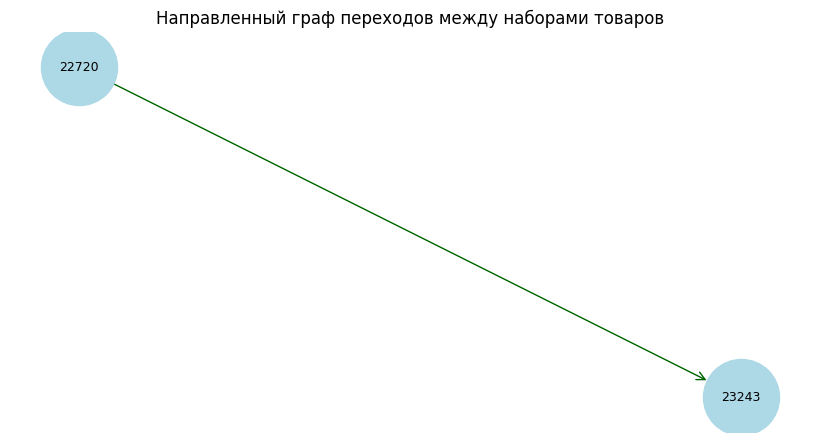

Покупка товара 22720 (SET OF 3 CAKE TINS PANTRY DESIGN) ведет к покупке товара 23243 (SET OF TEA COFFEE SUGAR TINS PANTRY) что свидетельствует о существующем спросе на покупку этой пары товаров. Позволяет составить таргетированную рекламу


In [17]:
candidates = [(seq, sup) for seq, sup in freq_inf.items()
              if len(seq) >= 2 and len(set(seq)) > 2]
if not candidates:
    candidates = [(seq, sup) for seq, sup in freq_inf.items() if len(seq) >= 2]

best_seq, best_sup = min(candidates, key=lambda x: (len(x[0]), x[1]))

print(f"Выбранный шаблон (длина {len(best_seq)}):")
print(' -> '.join(['(' + ','.join(sorted(map(str,it))) + ')' for it in best_seq]))
print(f"Поддержка: {best_sup:.3f}")

G = nx.DiGraph()
if len(set(best_seq)) == 1:
    label = ','.join(sorted(map(str, best_seq[0])))
    for i in range(len(best_seq)):
        G.add_node(f"{label}\n(транз. {i+1})")
    for i in range(len(best_seq)-1):
        G.add_edge(f"{label}\n(транз. {i+1})", f"{label}\n(транз. {i+2})")
else:
    for i in range(len(best_seq)-1):
        src = '\n'.join(sorted(map(str, best_seq[i])))
        dst = '\n'.join(sorted(map(str, best_seq[i+1])))
        G.add_edge(src, dst)

plt.figure(figsize=(8,4))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='darkgreen',
        node_size=3000, font_size=9, arrows=True, arrowstyle='->', arrowsize=15)
plt.title('Направленный граф переходов между наборами товаров')
plt.axis('off')
plt.show()

print("Покупка товара 22720 (SET OF 3 CAKE TINS PANTRY DESIGN) ведет к покупке товара 23243 (SET OF TEA COFFEE SUGAR TINS PANTRY) что свидетельствует о существующем спросе на покупку этой пары товаров. Позволяет составить таргетированную рекламу")

# Задание 3. Сравнение алгоритмов SPM

Синтетических клиентов: 500
Пример последовательности: [frozenset({791}), frozenset({607}), frozenset({278}), frozenset({500}), frozenset({892})]

PrefixSpan : найдено 7 паттернов, время 0.0097 с
AprioriAll : найдено 7 паттернов, время 0.0047 с
Внедрённый паттерн найден: PrefixSpan – True, AprioriAll – True


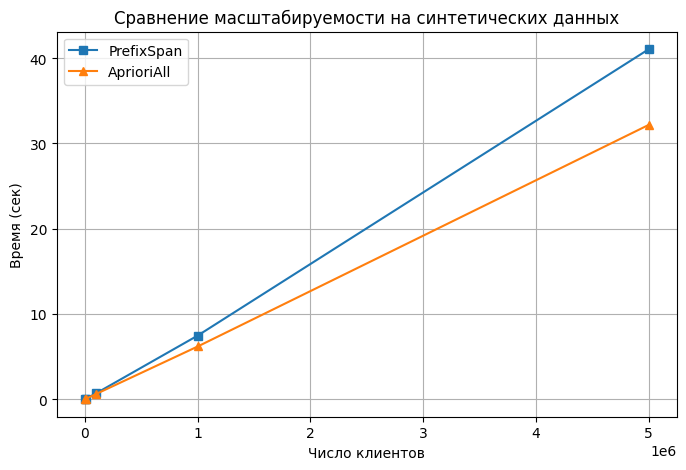

Вывод: PrefixSpan масштабируется лучше на больших объёмах.


In [76]:
import random
import time
import matplotlib.pyplot as plt

from prefixspan import PrefixSpan

def generate_synthetic_sequences(n_clients, pattern, pattern_support=0.5, avg_seq_len=6):
    """
    Генерирует последовательности с внедрённым pattern (кортеж frozenset одиночных товаров).
    """
    seqs = []
    for _ in range(n_clients):
        seq = []
        length = max(2, int(random.gauss(avg_seq_len, 2)))
        if random.random() < pattern_support:
            start = random.randint(0, max(0, length - len(pattern)))
            idx = 0
            for pos in range(length):
                if start <= pos < start + len(pattern):
                    seq.append(pattern[idx])
                    idx += 1
                else:
                    seq.append(frozenset([random.randint(1, 1000)]))
        else:
            seq = [frozenset([random.randint(1, 1000)]) for _ in range(length)]
        seqs.append(seq)
    return seqs


true_pattern = (frozenset([1]), frozenset([2]), frozenset([3]))
synth_data = generate_synthetic_sequences(500, true_pattern, pattern_support=0.6, avg_seq_len=6)
print(f"Синтетических клиентов: {len(synth_data)}")
print("Пример последовательности:", synth_data[0])


def to_prefixspan_format(seqs):
    """
    Преобразует последовательности frozenset в формат для PrefixSpan.
    Каждая транзакция превращается в строку, где элементы сортированы и разделены '-'.
    """
    ps_data = []
    for seq in seqs:
        ps_seq = []
        for iset in seq:
            items = sorted([int(x) for x in iset if isinstance(x, int) or str(x).isdigit()])
            if items:
                ps_seq.append("-".join(map(str, items)))
        if len(ps_seq) >= 2:
            ps_data.append(ps_seq)
    return ps_data

ps_input = to_prefixspan_format(synth_data)
abs_min_sup = max(1, int(0.05 * len(ps_input)))

# PrefixSpan
start = time.perf_counter()
ps = PrefixSpan(ps_input)
patterns_ps = ps.frequent(abs_min_sup)
time_ps = time.perf_counter() - start

# AprioriAll
min_sup_frac = abs_min_sup / len(synth_data)
start = time.perf_counter()
freq_our = apriori_all(synth_data, min_sup_frac)
time_our = time.perf_counter() - start

print(f"\nPrefixSpan : найдено {len(patterns_ps)} паттернов, время {time_ps:.4f} с")
print(f"AprioriAll : найдено {len(freq_our)} паттернов, время {time_our:.4f} с")

# Проверка, найден ли внедрённый паттерн (полнота)
target_ps_list = ["-".join(map(str, sorted(it))) for it in true_pattern]  
found_ps = any(list(p[1]) == target_ps_list for p in patterns_ps)  
found_our = true_pattern in freq_our
print(f"Внедрённый паттерн найден: PrefixSpan – {found_ps}, AprioriAll – {found_our}")

sizes = [1000, 10000, 100000, 1000000, 5000000]
times_ps = []
times_our = []
for n in sizes:
    data = generate_synthetic_sequences(n, true_pattern, pattern_support=0.6, avg_seq_len=6)
    ps_in = to_prefixspan_format(data)
    abs_sup = max(1, int(0.05 * len(ps_in)))

    t0 = time.perf_counter()
    PrefixSpan(ps_in).frequent(abs_sup)
    t_ps = time.perf_counter() - t0

    t0 = time.perf_counter()
    apriori_all(data, abs_sup / len(data))
    t_our = time.perf_counter() - t0

    times_ps.append(t_ps)
    times_our.append(t_our)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times_ps, marker='s', label='PrefixSpan')
plt.plot(sizes, times_our, marker='^', label='AprioriAll')
plt.xlabel('Число клиентов')
plt.ylabel('Время (сек)')
plt.title('Сравнение масштабируемости на синтетических данных')
plt.legend()
plt.grid(True)
plt.show()
print("Вывод: PrefixSpan масштабируется лучше на больших объёмах.")

# Задание 4. Предсказание следующего события (контекстные последовательности)

In [79]:
"""
Модель: если история клиента заканчивается набором X, предсказываем такой отдельный товар y,
что последовательность <{X}, {y}> является частой (длины 2) и имеет максимальную поддержку.
Оцениваем accuracy@1 – долю случаев, когда предсказанный товар действительно присутствует
в реальной следующей транзакции. Сравниваем с рекомендацией самого популярного товара.
"""

from collections import Counter

train_seqs = []   
test_samples = [] 

for idx, seq in enumerate(customer_sequences):
    if len(seq) < 2:
        continue
    split = max(1, int(0.8 * len(seq)))
    train_part = seq[:split]
    test_part = seq[split:]
    if test_part:
        train_seqs.append(train_part)
        test_samples.append((idx, train_part[-1], test_part[0]))

print(f"Клиентов в обучении: {len(train_seqs)}")
print(f"Тестовых примеров: {len(test_samples)}")

min_sup = 0.05
freq_seq_train = apriori_all(train_seqs, min_sup)

predict_rules = defaultdict(list) 
for seq, sup in freq_seq_train.items():
    if len(seq) == 2 and len(seq[1]) == 1: 
        y = next(iter(seq[1])) 
        context = seq[0]
        predict_rules[context].append((y, sup))

best_predictions = {}
for context, candidates in predict_rules.items():
    best_y, best_sup = max(candidates, key=lambda x: x[1])
    best_predictions[context] = best_y

print(f"Построено правил предсказания для {len(best_predictions)} контекстов")

item_counts = Counter()
for seq in train_seqs:
    for iset in seq:
        item_counts.update(iset)
global_top_item = item_counts.most_common(1)[0][0] if item_counts else None
print(f"Глобально самый частый товар: {global_top_item}")

correct_seq = 0
correct_baseline = 0
total = len(test_samples)
no_prediction = 0

for cust_id, context, real_next in test_samples:
    pred_y = best_predictions.get(context)
    if pred_y is not None and pred_y in real_next:
        correct_seq += 1
    elif pred_y is None:
        no_prediction += 1

    # Базовый подход
    if global_top_item is not None and global_top_item in real_next:
        correct_baseline += 1

acc_seq = correct_seq / total
acc_base = correct_baseline / total

print(f"\nРезультаты на тестовой выборке ({total} примеров):")
print(f"Точность модели на основе последовательностей (accuracy@1): {acc_seq:.3f} ({correct_seq} верных)")
print(f"Точность глобального топ-товара: {acc_base:.3f} ({correct_baseline} верных)")
print(f"Доля примеров без предсказания (отсутствовало правило): {no_prediction/total:.2%}")

Клиентов в обучении: 2847
Тестовых примеров: 2847
Построено правил предсказания для 23 контекстов
Глобально самый частый товар: 85123A

Результаты на тестовой выборке (2847 примеров):
Точность модели на основе последовательностей (accuracy@1): 0.004 (10 верных)
Точность глобального топ-товара: 0.084 (240 верных)
Доля примеров без предсказания (отсутствовало правило): 99.51%


# Задание 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»

HighValue (выручка ≥ 1662): 1085 клиентов
LowValue: 3253 клиентов
HighValue seqs: 1054, LowValue seqs: 1793

Топ-5 контрастных последовательностей (реальные переходы, чаще у HighValue):
1. 85099B -> 23203 | diff=0.184 (h=0.184, l=0.000)
2. 20725 -> 23209 | diff=0.172 (h=0.172, l=0.000)
3. 85099B -> 20725 | diff=0.171 (h=0.171, l=0.000)
4. 20725 -> 85099B | diff=0.168 (h=0.168, l=0.000)
5. 23203 -> 85099B | diff=0.163 (h=0.163, l=0.000)

Визуализация: длина 2, контраст 0.184
  (85099B) -> (23203)


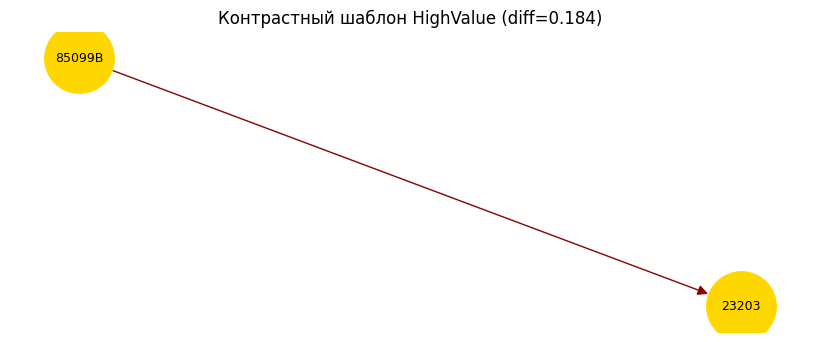


Бизнес-гипотеза: клиенты, покупающие сначала {85099B}, а затем {23203}, с большей вероятностью становятся высокодоходными. Можно использовать эту цепочку для таргетированных промо-акций на раннем этапе, повышая LTV.


In [80]:
revenue = df.groupby('CustomerID').apply(lambda g: (g['Quantity'] * g['UnitPrice']).sum())
threshold = revenue.quantile(0.75)
high_ids = set(revenue[revenue >= threshold].index)
low_ids = set(revenue[revenue < threshold].index)
print(f"HighValue (выручка ≥ {threshold:.0f}): {len(high_ids)} клиентов")
print(f"LowValue: {len(low_ids)} клиентов")

def get_class_sequences(cust_ids):
    seqs = []
    temp_grouped = temp[temp['CustomerID'].isin(cust_ids)]
    for cust, group in temp_grouped.groupby('CustomerID'):
        seq = group['StockCode'].tolist()
        if len(seq) >= 2:
            seqs.append(seq)
    return seqs

high_seqs = get_class_sequences(high_ids)
low_seqs = get_class_sequences(low_ids)
print(f"HighValue seqs: {len(high_seqs)}, LowValue seqs: {len(low_seqs)}")

min_sup = 0.1
freq_high = apriori_all(high_seqs, min_sup)
freq_low = apriori_all(low_seqs, min_sup)

contrast_candidates = {}
for seq in set(freq_high.keys()) | set(freq_low.keys()):
    if len(seq) < 2 or len(set(seq)) == 1:
        continue
    sup_h = freq_high.get(seq, 0.0)
    sup_l = freq_low.get(seq, 0.0)
    diff = sup_h - sup_l
    if diff > 0:
        contrast_candidates[seq] = diff

if not contrast_candidates:
    print("\nНет контрастных последовательностей с реальными переходами.")
else:
    # Топ-5 по контрасту
    top5 = sorted(contrast_candidates.items(), key=lambda x: -x[1])[:5]
    print("\nТоп-5 контрастных последовательностей (реальные переходы, чаще у HighValue):")
    for i, (seq, diff) in enumerate(top5, 1):
        sup_h = freq_high.get(seq, 0)
        sup_l = freq_low.get(seq, 0)
        def fmt(iset):
            items = sorted(map(str, iset))
            return items[0] if len(items) == 1 else ",".join(items)
        s = " -> ".join(fmt(it) for it in seq)
        print(f"{i}. {s} | diff={diff:.3f} (h={sup_h:.3f}, l={sup_l:.3f})")

    best_seq = max(top5, key=lambda item: (len(item[0]), item[1]))[0]
    best_diff = contrast_candidates[best_seq]
    sup_h = freq_high[best_seq]
    sup_l = freq_low.get(best_seq, 0.0)

    print(f"\nВизуализация: длина {len(best_seq)}, контраст {best_diff:.3f}")
    s_vis = " -> ".join(
        "(" + ",".join(sorted(map(str, it))) + ")" for it in best_seq
    )
    print(f"  {s_vis}")

    G = nx.DiGraph()
    for i in range(len(best_seq)-1):
        src = ",".join(sorted(map(str, best_seq[i])))
        dst = ",".join(sorted(map(str, best_seq[i+1])))
        G.add_edge(src, dst)

    plt.figure(figsize=(8, 3))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='gold', edge_color='darkred',
            node_size=2500, font_size=9, arrows=True, arrowsize=15)
    plt.title(f"Контрастный шаблон HighValue (diff={best_diff:.3f})")
    plt.axis('off')
    plt.show()

    first_items = ", ".join(sorted(map(str, best_seq[0])))
    last_items = ", ".join(sorted(map(str, best_seq[-1])))
    print(f"\nБизнес-гипотеза: клиенты, покупающие сначала {{{first_items}}}, "
          f"а затем {{{last_items}}}, с большей вероятностью становятся высокодоходными. "
          "Можно использовать эту цепочку для таргетированных промо-акций на раннем этапе, "
          "повышая LTV.")

Показанные шаблоны в основной являются связями покупок разничных цветов сумок (JUMBO BAG RED RETROSPOT, JUMBO BAG DOILEY PATTERNS, LUNCH BAG DOILEY PATTERN), что может указывать на желание собрать набор или оптовую закупку. В обоих случаях целесообразно предлагать другие стили при покупке одного из этих товаров.